In [2]:
import os
import json
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score

# Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration (CPU / GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn import hmm

np.random.seed(42)

# ---------------------------------------------------------
# 1. LOAD DATA
# ---------------------------------------------------------
df = pd.read_excel('master_dataset.xlsx', parse_dates=['Date'])
df = df.sort_values('Date').set_index('Date')
df = df.asfreq('B').ffill()

# ---------------------------------------------------------
# 2. FEATURE ENGINEERING
# ---------------------------------------------------------

# --- Market (NGX) ---
df['NGX_Return'] = np.log(df['ASI'] / df['ASI'].shift(1))
df['NGX_Vol']    = df['NGX_Return'].rolling(10).std()

# --- FX (USD/NGN) ---
df['FX_Return'] = np.log(df['USDNGN'] / df['USDNGN'].shift(1))
df['FX_Vol']    = df['FX_Return'].rolling(10).std()
df['FX_Trend']  = df['USDNGN'].rolling(30).mean()
df['FX_Trend_Raw'] = (df['USDNGN'] - df['FX_Trend']) / df['FX_Trend']

# --- FPI ---
df['FPI_Z'] = (df['Net FPI'] - df['Net FPI'].rolling(60).mean()) / df['Net FPI'].rolling(60).std()
df['FPI_Z'] = df['FPI_Z'].clip(-3, 3)

# --- Bond & Oil ---
df['Bond_Change']  = df['Bond_10Y'].diff()
df['Brent_Return'] = np.log(df['Brent_Crude'] / df['Brent_Crude'].shift(1))

# --- NGX Sharpe Z (risk-adjusted return signal, NOT momentum) ---
# Standard in regime-switching literature (see Ang & Timmermann 2012)
df['NGX_Sharpe_Z'] = df['NGX_Return'].rolling(20).mean() / \
    df['NGX_Return'].rolling(20).std()
df['NGX_Sharpe_Z'] = df['NGX_Sharpe_Z'].clip(-3, 3)

# --- Rolling Z-score ALL continuous features (single standardization pass) ---
# This replaces both the old StandardScaler AND the old raw features
for col in ['NGX_Return', 'NGX_Vol', 'FX_Return', 'FX_Vol', 'FX_Trend_Raw']:
    roll_mean = df[col].rolling(60).mean()
    roll_std  = df[col].rolling(60).std().replace(0, np.nan)
    df[f'{col}_Z'] = ((df[col] - roll_mean) / roll_std).clip(-3, 3)

df = df.dropna()

In [4]:
df.head()

,ASI,USDNGN,Net FPI,Bond_10Y,Brent_Crude,NGX_Return,NGX_Vol,FX_Return,FX_Vol,FX_Trend,FX_Trend_Raw,FPI_Z,Bond_Change,Brent_Return,NGX_Sharpe_Z,NGX_Return_Z,NGX_Vol_Z,FX_Return_Z,FX_Vol_Z,FX_Trend_Raw_Z
Date,,,,,,,,,,,,,,,,,,,,
1997-01-01,6992.10,74.36,1.653120e+09,13.5,23.99,0.000000,0.000708,0.000000,0.013718,78.784000,-0.056154,-3.0,0.0,0.007531,0.833166,-0.780422,-1.925269,0.172681,3.0,-3.000000
1997-01-02,6992.01,75.50,1.653120e+09,13.5,24.22,-0.000013,0.000485,0.015214,0.015302,78.651267,-0.040066,-3.0,0.0,0.009542,0.750702,-0.764507,-2.451991,2.401189,3.0,-2.995715
1997-01-03,6999.95,73.10,1.653120e+09,13.5,24.12,0.001135,0.000546,-0.032304,0.017443,78.440533,-0.068084,-3.0,0.0,-0.004137,0.746814,0.056305,-2.144981,-3.000000,3.0,-3.000000
1997-01-06,6988.82,75.76,1.653120e+09,13.5,24.56,-0.001591,0.000794,0.035742,0.022250,78.315867,-0.032635,-3.0,0.0,0.018078,0.593172,-1.817860,-1.385001,3.000000,3.0,-1.790595
1997-01-07,6997.84,74.30,1.653120e+09,13.5,24.59,0.001290,0.000870,-0.019459,0.022811,78.146467,-0.049221,-3.0,0.0,0.001221,0.566544,0.166968,-1.142380,-1.934991,3.0,-2.672902


In [5]:
import numpy as np
import pandas as pd
import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

class TimeSeriesTradingSystem:
    def __init__(self, data_source, period='10y'):
        """
        data_source can be:
        - a pandas DataFrame with a 'Close' column
        - a pandas Series of prices
        - a string representing a local CSV file path
        - a string representing a yfinance ticker (e.g., 'SPY', '^NSEI')
        """
        self.data_source = data_source
        self.period = period
        self.prices = None
        self.returns = None
        
    def fetch_and_prepare(self):
        if isinstance(self.data_source, pd.DataFrame):
            if 'Close' in self.data_source.columns:
                self.prices = self.data_source['Close']
            else:
                self.prices = self.data_source.iloc[:, 0]
        elif isinstance(self.data_source, pd.Series):
            self.prices = self.data_source
        elif isinstance(self.data_source, str):
            import os
            if self.data_source.endswith('.csv') or os.path.exists(self.data_source):
                df = pd.read_csv(self.data_source)
                if 'Date' in df.columns:
                    for fmt in ['%d/%m/%Y', '%Y-%m-%d', '%m/%d/%Y']:
                        try:
                            df['Date'] = pd.to_datetime(df['Date'], format=fmt)
                            break
                        except:
                            continue
                    if not pd.api.types.is_datetime64_any_dtype(df['Date']):
                        df['Date'] = pd.to_datetime(df['Date'])
                    df = df.drop_duplicates('Date').set_index('Date').sort_index()
                
                if 'ASI' in df.columns:
                    df = df.rename(columns={'ASI': 'Close'})
                
                if 'Close' in df.columns:
                    self.prices = df['Close']
                else:
                    self.prices = df.iloc[:, 0]
            else:
                df = yf.Ticker(self.data_source).history(period=self.period)
                self.prices = df['Close']
        else:
            raise ValueError("Unsupported data source format")
            
        self.returns = np.log(self.prices / self.prices.shift(1)).dropna() * 100
        return self.returns
    
    def check_stationarity(self, series):
        result = adfuller(series.dropna())
        print(f"ADF Statistic: {result[0]:.4f}")
        print(f"P-value: {result[1]:.4f}")
        print(f"Stationary: {result[1] < 0.05}")
        return result[1] < 0.05
    
    def fit_arima_garch(self, returns, arima_order=(1,0,1), garch_order=(1,1)):
        arima = ARIMA(returns, order=arima_order)
        arima_result = arima.fit()
        residuals = arima_result.resid
        
        garch = arch_model(residuals, vol='Garch', p=garch_order[0], q=garch_order[1])
        garch_result = garch.fit(disp='off')
        
        return arima_result, garch_result
    
    def generate_signals(self, returns, lookback=252, max_predictions=500):
        """
        Generate trading signals using a rolling ARIMA-GARCH model.
        To avoid very long computation times on large historical datasets,
        max_predictions limits predictions to the most recent N days.
        """
        signals = []
        
        start_idx = lookback
        if max_predictions is not None:
            start_idx = max(lookback, len(returns) - max_predictions)
            
        print(f"Generating signals for {len(returns) - start_idx} periods (from index {start_idx} to {len(returns)})...")
        
        for i in range(start_idx, len(returns)):
            window = returns.iloc[i-lookback:i]
            
            if (i - start_idx) % 100 == 0 or i == len(returns) - 1:
                print(f"Progress: {i - start_idx}/{len(returns) - start_idx} steps...")
                
            try:
                arima = ARIMA(window, order=(1,0,1)).fit()
                forecast = arima.forecast(steps=1).iloc[0] if hasattr(arima.forecast(steps=1), 'iloc') else arima.forecast(steps=1)[0]
                
                garch = arch_model(arima.resid, vol='Garch', p=1, q=1).fit(disp='off')
                vol_forecast = np.sqrt(garch.forecast(horizon=1).variance.values[-1][0])
                
                signal = 1 if forecast > 0 else -1
                position_size = min(1.0, 1.0 / max(vol_forecast, 0.1))
                scaled_signal = signal * position_size
                
            except Exception as e:
                scaled_signal = 0
                
            signals.append({
                'date': returns.index[i],
                'signal': scaled_signal
            })
        
        print("Signal generation complete.")
        return pd.DataFrame(signals).set_index('date')

# Initialize system using preprocessed 'data' DataFrame
system = TimeSeriesTradingSystem(df)
returns = system.fetch_and_prepare()

print("Checking stationarity of returns:")
system.check_stationarity(returns)

arima_result, garch_result = system.fit_arima_garch(returns)
print(f"\nARIMA AIC: {arima_result.aic:.2f}")
print(f"GARCH Log-likelihood: {garch_result.loglikelihood:.2f}")

# Generate signals for the last 500 trading days (~2 years)
# To run on the entire dataset, set max_predictions=None
signals = system.generate_signals(returns, max_predictions=500)
strategy_returns = signals['signal'].shift(1) * returns.loc[signals.index]

sharpe = strategy_returns.mean() / strategy_returns.std() * np.sqrt(252)
cumulative = (1 + strategy_returns / 100).cumprod()
max_dd = ((cumulative - cumulative.cummax()) / cumulative.cummax()).min()

print(f"\nSystem Performance:")
print(f"Annualized Sharpe: {sharpe:.4f}")
print(f"Maximum Drawdown: {max_dd:.4f}")

Checking stationarity of returns:
ADF Statistic: -45.8748
P-value: 0.0000
Stationary: True

ARIMA AIC: 19397.72
GARCH Log-likelihood: -9341.38
Generating signals for 500 periods (from index 3850 to 4350)...
Progress: 0/500 steps...
Progress: 100/500 steps...
Progress: 200/500 steps...
Progress: 300/500 steps...
Progress: 400/500 steps...
Progress: 499/500 steps...
Signal generation complete.

System Performance:
Annualized Sharpe: 4.2939
Maximum Drawdown: -0.0460


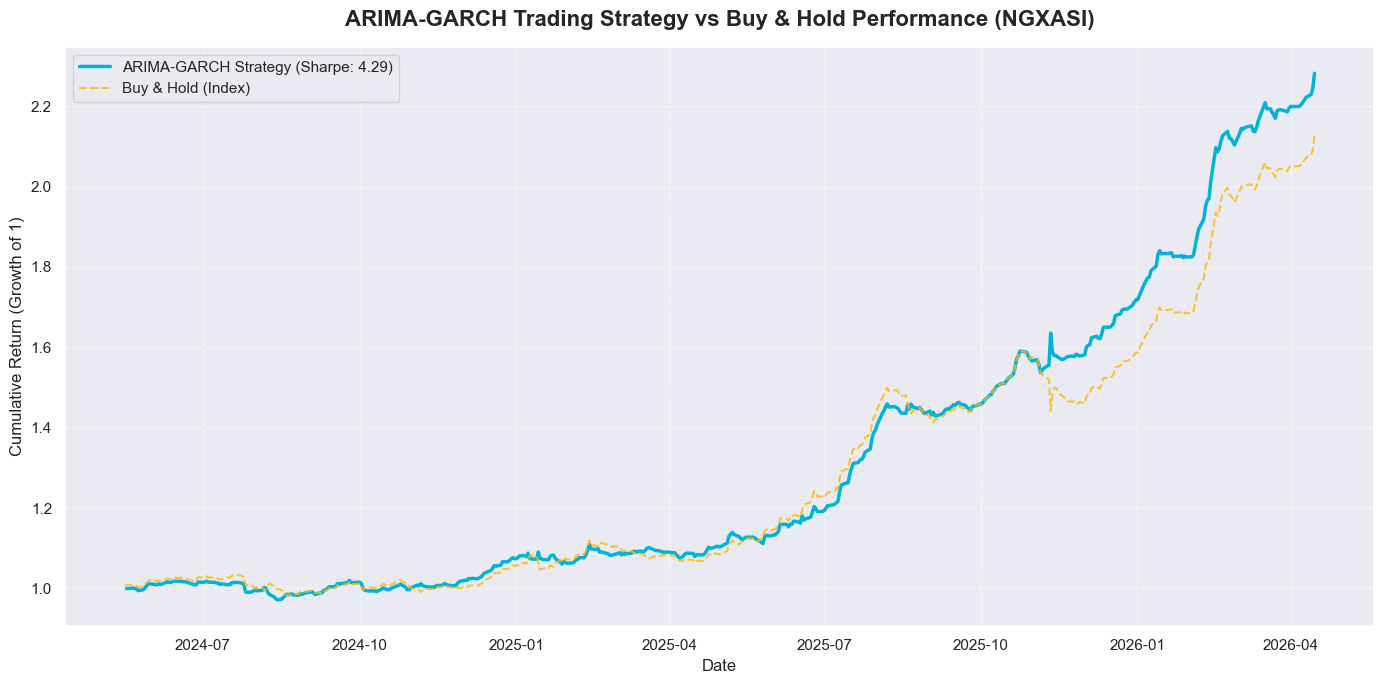

In [6]:
# Plot results dynamically and beautifully
import matplotlib.pyplot as plt
import seaborn as sns

try:
    sns.set_theme(style="darkgrid")
except:
    plt.style.use('seaborn-v0_8-darkgrid' if 'seaborn-v0_8-darkgrid' in plt.style.available else 'default')

plt.figure(figsize=(14, 7), dpi=100)

strategy_cum = (1 + strategy_returns / 100).cumprod()
buy_hold_cum = (1 + returns.loc[signals.index] / 100).cumprod()

plt.plot(strategy_cum.index, strategy_cum, label=f'ARIMA-GARCH Strategy (Sharpe: {sharpe:.2f})', color='#00b4d8', linewidth=2.5)
plt.plot(buy_hold_cum.index, buy_hold_cum, label='Buy & Hold (Index)', color='#ffb703', linewidth=1.5, linestyle='--', alpha=0.8)

plt.title('ARIMA-GARCH Trading Strategy vs Buy & Hold Performance (NGXASI)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return (Growth of 1)', fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [7]:
# Compute annual returns year by year
from IPython.display import display
import numpy as np
import pandas as pd

strategy_daily_ret = strategy_returns / 100
buy_hold_daily_ret = returns.loc[signals.index] / 100

# Annualized metrics by calendar year
annual_perf = []

years = sorted(strategy_daily_ret.index.year.unique())

for year in years:
    strat_yr = strategy_daily_ret[
        strategy_daily_ret.index.year == year
    ]
    
    bh_yr = buy_hold_daily_ret[
        buy_hold_daily_ret.index.year == year
    ]

    # Cumulative return for the year
    strat_ret = (1 + strat_yr).prod() - 1
    bh_ret = (1 + bh_yr).prod() - 1

    # Volatility for the year (annualized)
    strat_vol = strat_yr.std() * np.sqrt(252)
    bh_vol = bh_yr.std() * np.sqrt(252)

    # Sharpe ratio for the year
    strat_sharpe = (
        strat_yr.mean() / strat_yr.std() * np.sqrt(252)
        if strat_yr.std() > 0 else 0
    )

    bh_sharpe = (
        bh_yr.mean() / bh_yr.std() * np.sqrt(252)
        if bh_yr.std() > 0 else 0
    )

    annual_perf.append({
        'Year': year,
        'Strategy Return (%)': strat_ret * 100,
        'Buy & Hold Return (%)': bh_ret * 100,
        'Strategy Volatility (%)': strat_vol * 100,
        'Buy & Hold Volatility (%)': bh_vol * 100,
        'Strategy Sharpe': strat_sharpe,
        'Buy & Hold Sharpe': bh_sharpe
    })

df_annual = pd.DataFrame(annual_perf).set_index('Year')

# Overall Performance Summary
overall_perf = []

for name, daily_ret in [
    ('ARIMA-GARCH Strategy', strategy_daily_ret),
    ('Buy & Hold', buy_hold_daily_ret)
]:
    
    cum_ret = (1 + daily_ret).prod() - 1

    ann_ret = (1 + cum_ret) ** (
        252 / len(daily_ret)
    ) - 1

    ann_vol = daily_ret.std() * np.sqrt(252)

    sharpe_ratio = (
        daily_ret.mean() / daily_ret.std() * np.sqrt(252)
    )

    # Drawdown
    cum_series = (1 + daily_ret).cumprod()

    dd = (
        (cum_series - cum_series.cummax()) /
        cum_series.cummax()
    )

    max_drawdown = dd.min()

    overall_perf.append({
        'Metric': name,
        'Cumulative Return (%)': cum_ret * 100,
        'Annualized Return (%)': ann_ret * 100,
        'Annualized Volatility (%)': ann_vol * 100,
        'Sharpe Ratio': sharpe_ratio,
        'Max Drawdown (%)': max_drawdown * 100
    })

df_overall = pd.DataFrame(overall_perf).set_index('Metric')

print("=== YEAR-BY-YEAR PERFORMANCE ===")
display(df_annual.round(2))

print("\n=== OVERALL PERFORMANCE SUMMARY ===")
display(df_overall.round(2))

=== YEAR-BY-YEAR PERFORMANCE ===


,Strategy Return (%),Buy & Hold Return (%),Strategy Volatility (%),Buy & Hold Volatility (%),Strategy Sharpe,Buy & Hold Sharpe
Year,,,,,,
2024,7.42,5.60,6.09,6.18,1.85,1.39
2025,59.93,50.22,10.64,10.84,4.32,3.68
2026,32.82,34.13,12.24,12.45,7.87,8.00



=== OVERALL PERFORMANCE SUMMARY ===


,Cumulative Return (%),Annualized Return (%),Annualized Volatility (%),Sharpe Ratio,Max Drawdown (%)
Metric,,,,,
ARIMA-GARCH Strategy,128.17,51.55,9.82,4.29,-4.60
Buy & Hold,112.79,46.31,10.01,3.86,-9.34
